In [17]:
import pandas as pd
df=pd.read_csv("agri_data (1) (2).csv")
print(df)

   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  \
0  2018  North  Wheat           1200             3600          800   
1  2018  South   Rice           1500             5000         1200   
2  2019  North  Wheat           1250             3700          820   
3  2019  South   Rice           1600             5200         1150   
4  2020  North  Wheat           1300             3900          780   
5  2020  South   Rice           1700             5400         1300   
6  2021  North  Wheat           1280             4000          900   
7  2021  South   Rice           1750             5600         1250   
8  2022  North  Wheat           1350             4200          850   
9  2022  South   Rice           1800             6000         1400   

   Temperature_C  
0             22  
1             28  
2             23  
3             29  
4             24  
5             30  
6             23  
7             31  
8             25  
9             32  


In [18]:
len(df) #number of rows

10

In [20]:
len(df.columns) #number of columns

7

In [26]:
print(df.tail(4)) # to print bottom rows

   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  \
6  2021  North  Wheat           1280             4000          900   
7  2021  South   Rice           1750             5600         1250   
8  2022  North  Wheat           1350             4200          850   
9  2022  South   Rice           1800             6000         1400   

   Temperature_C  
6             23  
7             31  
8             25  
9             32  


In [33]:
df["Rainfall_mm"]

,Rainfall_mm
0,800
1,1200
2,820
3,1150
4,780
5,1300
6,900
7,1250
8,850
9,1400


In [30]:
print("\ndata info") #gives basic information

print(df.info)


data info
<bound method DataFrame.info of    Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  \
0  2018  North  Wheat           1200             3600          800   
1  2018  South   Rice           1500             5000         1200   
2  2019  North  Wheat           1250             3700          820   
3  2019  South   Rice           1600             5200         1150   
4  2020  North  Wheat           1300             3900          780   
5  2020  South   Rice           1700             5400         1300   
6  2021  North  Wheat           1280             4000          900   
7  2021  South   Rice           1750             5600         1250   
8  2022  North  Wheat           1350             4200          850   
9  2022  South   Rice           1800             6000         1400   

   Temperature_C  
0             22  
1             28  
2             23  
3             29  
4             24  
5             30  
6             23  
7             31  
8             2

In [24]:
print(df.head(8)) #to print top rows

   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  \
0  2018  North  Wheat           1200             3600          800   
1  2018  South   Rice           1500             5000         1200   
2  2019  North  Wheat           1250             3700          820   
3  2019  South   Rice           1600             5200         1150   
4  2020  North  Wheat           1300             3900          780   
5  2020  South   Rice           1700             5400         1300   
6  2021  North  Wheat           1280             4000          900   
7  2021  South   Rice           1750             5600         1250   

   Temperature_C  
0             22  
1             28  
2             23  
3             29  
4             24  
5             30  
6             23  
7             31  


In [38]:
#filter data(only wheat)
wheat_data=df[df["Crop"]=="wheat"]
print("\nwheat data:")
print(wheat_data)




wheat data:
Empty DataFrame
Columns: [Year, Region, Crop, Area_Hectares, Production_Tons, Rainfall_mm, Temperature_C]
Index: []


In [44]:

grouped_data=df.groupby("Crop")["Production_Tons"].sum()
print("\ngrouped data:")
print(grouped_data)


grouped data:
Crop
Rice     27200
Wheat    19400
Name: Production_Tons, dtype: int64


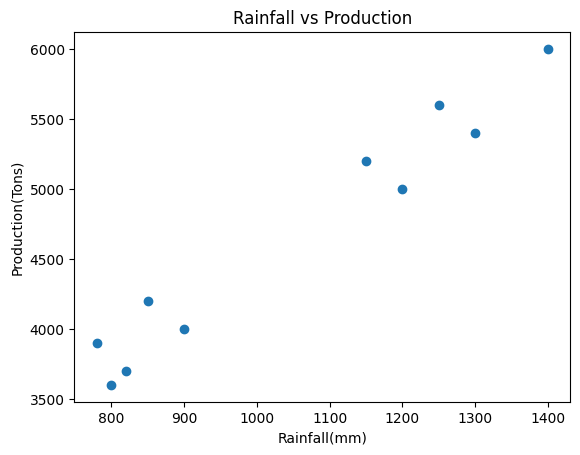

In [49]:
#scatter plt , rainfall vs production
import matplotlib.pyplot as plt
plt.scatter(df["Rainfall_mm"],df["Production_Tons"])
plt.xlabel("Rainfall(mm)")
plt.ylabel("Production(Tons)")
plt.title("Rainfall vs Production")
plt.show()

In [51]:
#group by year and  sum production
yearly_production=df.groupby("Year")["Production_Tons"].sum()
print("\nyearly production:")
print(yearly_production)
print(yearly_production.index)
print(yearly_production)



yearly production:
Year
2018     8600
2019     8900
2020     9300
2021     9600
2022    10200
Name: Production_Tons, dtype: int64
Index([2018, 2019, 2020, 2021, 2022], dtype='int64', name='Year')
[ 8600  8900  9300  9600 10200]


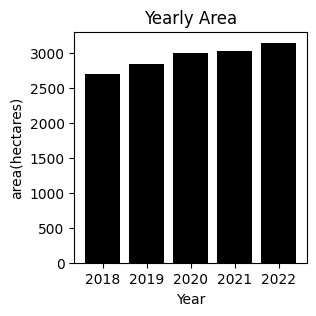

In [77]:
area_by_year=df.groupby("Year")["Area_Hectares"].sum()
plt.figure(figsize=(3,3))
plt.bar(area_by_year.index,area_by_year.values,color="black")
plt.xlabel("Year")
plt.ylabel("area(hectares)")
plt.title("Yearly Area")
plt.xticks(yearly_production.index)
plt.show()

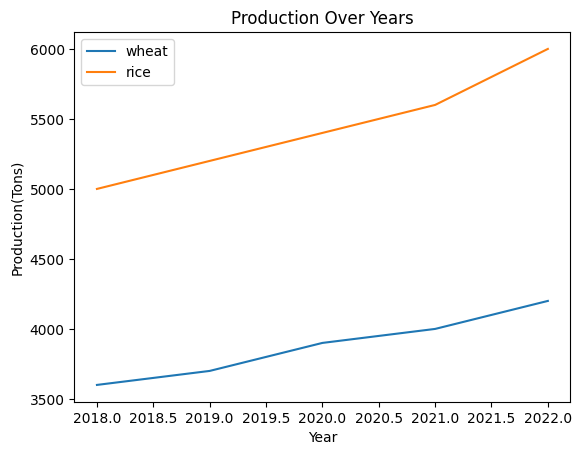

In [84]:
#line plot production over years without for loop
wheat=df[df["Crop"]=="Wheat"]
rice=df[df["Crop"]=="Rice"]
plt.figure()
plt.plot(wheat["Year"],wheat["Production_Tons"],label="wheat")
plt.plot(rice["Year"],rice["Production_Tons"],label="rice")
plt.xlabel("Year")
plt.ylabel("Production(Tons)")
plt.title("Production Over Years")
plt.legend()

   Year Region   Crop  Area_Hectares  Production_Tons  Rainfall_mm  \
8  2022  North  Wheat           1350             4200          850   
9  2022  South   Rice           1800             6000         1400   

   Temperature_C  
8             25  
9             32  


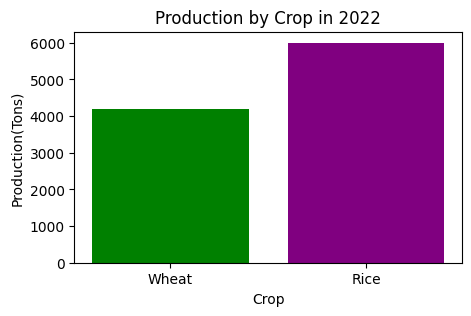

In [88]:
#bar plot - production  by crop(single year example:2022)
#filter year 2022
data_2022=df[df["Year"]==2022]
print(data_2022)
plt.figure(figsize=(5,3))
plt.bar(data_2022["Crop"],data_2022["Production_Tons"],color=["green","purple"])
plt.xlabel("Crop")
plt.ylabel("Production(Tons)")
plt.title("Production by Crop in 2022")
plt.show()

In [5]:
#custom styled bar plot
import matplotlib.pyplot as plt

yearly_production=df.groupby("Year")["Production_Tons"].sum()

plt.figure(figsize=(5,3))
bars=plt.bar(yearly_production.index,
             yearly_production.values,
             color='lightgreen',
             edgecolor='black')
#add value labels on top of the bars
for bar in bars:
  height=bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2,
           height,
           str(height),
           ha="center",
           va="bottom")
  plt.xlabel("year")
  plt.ylabel("production(tons)")
  plt.title("yearly production")
  plt.show()

NameError: name 'df' is not defined

In [4]:
import pandas as pd
df=pd.read_csv("agri_data (1) (2).csv")
#custom styled bar plot
import matplotlib.pyplot as plt

yearly_production=df.groupby("Year")["Production_Tons"].sum()

plt.figure(figsize=(5,3))
bars=plt.bar(yearly_production.index,
             yearly_production.values,
             color='lightgreen',
             edgecolor='black')
#add value labels on top of the bars
for bar in bars:
  height=bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2,
           height,
           str(height),
           ha="center",
           va="bottom")
  plt.xlabel("year")
  plt.ylabel("production(tons)")
  plt.title("yearly production")
  plt.show()

NameError: name 'df' is not defined

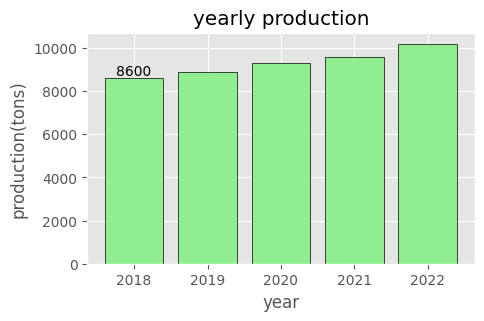

In [ ]:
import pandas as pd
df=pd.read_csv("agri_data (1) (2).csv")
#custom styled bar plot
import matplotlib.pyplot as plt

yearly_production=df.groupby("Year")["Production_Tons"].sum()

plt.figure(figsize=(5,3))
bars=plt.bar(yearly_production.index,
             yearly_production.values,
             color='lightgreen',
             edgecolor='black')
#add value labels on top of the bars
for bar in bars:
  height=bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2,
           height,
           str(height),
           ha="center",
           va="bottom")
  plt.xlabel("year")
  plt.ylabel("production(tons)")
  plt.title("yearly production")
  plt.show()